In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import cv2
from tqdm import tqdm
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
def create_custom_dataset(num_samples=1000, img_size=128):
    images = []
    masks = []

    for _ in range(num_samples):
        # Create blank image and mask
        img = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        mask = np.zeros((img_size, img_size), dtype=np.uint8)

        # Randomly choose to add circle or rectangle (or both)
        shapes_to_add = np.random.choice([1, 2], size=np.random.randint(1, 3), replace=False)

        for shape in shapes_to_add:
            if shape == 1:  # Circle
                center = (np.random.randint(20, img_size-20), np.random.randint(20, img_size-20))
                radius = np.random.randint(10, 25)
                color = (np.random.randint(100, 255), np.random.randint(100, 255), np.random.randint(100, 255))

                cv2.circle(img, center, radius, color, -1)
                cv2.circle(mask, center, radius, 1, -1)

            elif shape == 2:  # Rectangle
                x1, y1 = np.random.randint(10, img_size//2), np.random.randint(10, img_size//2)
                x2, y2 = x1 + np.random.randint(20, 40), y1 + np.random.randint(20, 40)
                x2, y2 = min(x2, img_size-10), min(y2, img_size-10)
                color = (np.random.randint(100, 255), np.random.randint(100, 255), np.random.randint(100, 255))

                cv2.rectangle(img, (x1, y1), (x2, y2), color, -1)
                cv2.rectangle(mask, (x1, y1), (x2, y2), 2, -1)

        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)

images, masks = create_custom_dataset(num_samples=800, img_size=128)

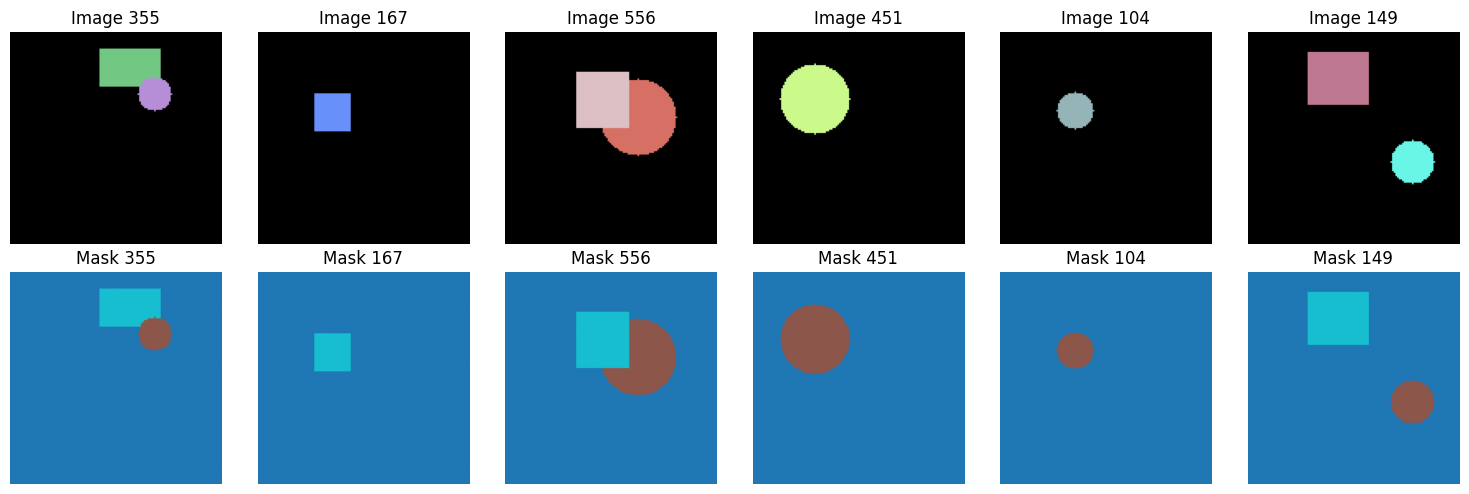


Class distribution in masks:
Class 0 (Background): 12001926 pixels (91.6%)
Class 1 (Circle): 561799 pixels (4.3%)
Class 2 (Rectangle): 543475 pixels (4.1%)


In [ ]:
# Visualize some samples
fig, axes = plt.subplots(2, 6, figsize=(15, 5))

for i in range(6):
    idx = np.random.randint(0, len(images))

    # Original image
    axes[0, i].imshow(images[idx])
    axes[0, i].set_title(f'Image {idx}')
    axes[0, i].axis('off')

    # Mask
    axes[1, i].imshow(masks[idx], cmap='tab10', vmax=2)
    axes[1, i].set_title(f'Mask {idx}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# Show class distribution
unique, counts = np.unique(masks, return_counts=True)
print("\nClass distribution in masks:")
for class_id, count in zip(unique, counts):
    class_names = ['Background', 'Circle', 'Rectangle']
    print(f"Class {class_id} ({class_names[class_id]}): {count} pixels ({count/masks.size*100:.1f}%)")

In [ ]:
class SegmentationDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        mask = self.masks[idx]

        image = torch.FloatTensor(image).permute(2,0,1) / 255.0
        mask = torch.LongTensor(mask)

        return image, mask



train_images, test_images, train_masks, test_masks = train_test_split(images, masks, test_size=0.2, random_state=42)

train_dataset = SegmentationDataset(train_images, train_masks)
test_dataset = SegmentationDataset(test_images, test_masks)


train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=3):
        super(SimpleCNN, self).__init__()

        self.encoder1 = self._conv_block(in_channels, 32)
        self.encoder2 = self._conv_block(32, 64)
        self.encoder3 = self._conv_block(64, 128)

        self.bottleneck = self._conv_block(128, 256)

        self.decoder3 = self._conv_block(256 + 128, 128)
        self.decoder2 = self._conv_block(128 + 64, 64)
        self.decoder1 = self._conv_block(64 + 32, 32)

        self.classifier = nn.Conv2d(32, num_classes, kernel_size=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)


    def _conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )


    def forward(self, x):
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool(enc1))
        enc3 = self.encoder3(self.pool(enc2))

        bottleneck = self.bottleneck(self.pool(enc3))

        dec3 = self.upsample(bottleneck)
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.decoder3(dec3)

        dec2 = self.upsample(dec3)
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.decoder2(dec2)

        dec1 = self.upsample(dec2)
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.decoder1(dec1)

        out = self.classifier(dec1)

        return out


model = SimpleCNN().to(device)

In [ ]:
def train_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for batch_idx, (images, masks) in enumerate(tqdm(train_loader, desc="Training")):
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()


    return total_loss / len(train_loader)



In [ ]:
def calculate_iou(pred_mask, true_mask, num_classes=3):
    ious = []
    pred_mask = pred_mask.view(-1)
    true_mask = true_mask.view(-1)

    for cls in range(num_classes):
        pred_inds = pred_mask == cls
        target_inds = true_mask == cls
        intersection = (pred_inds[target_inds]).sum().float()
        union = pred_inds.sum().float() + target_inds.sum().float() - intersection
        if union == 0:
            ious.append(float('nan'))  # If no union, IoU is undefined
        else:
            ious.append((intersection / union).item())

    return ious

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [ ]:
num_epochs = 20
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    train_losses.append(train_loss)

    scheduler.step()

Training: 100%|██████████| 40/40 [00:03<00:00, 12.52it/s]


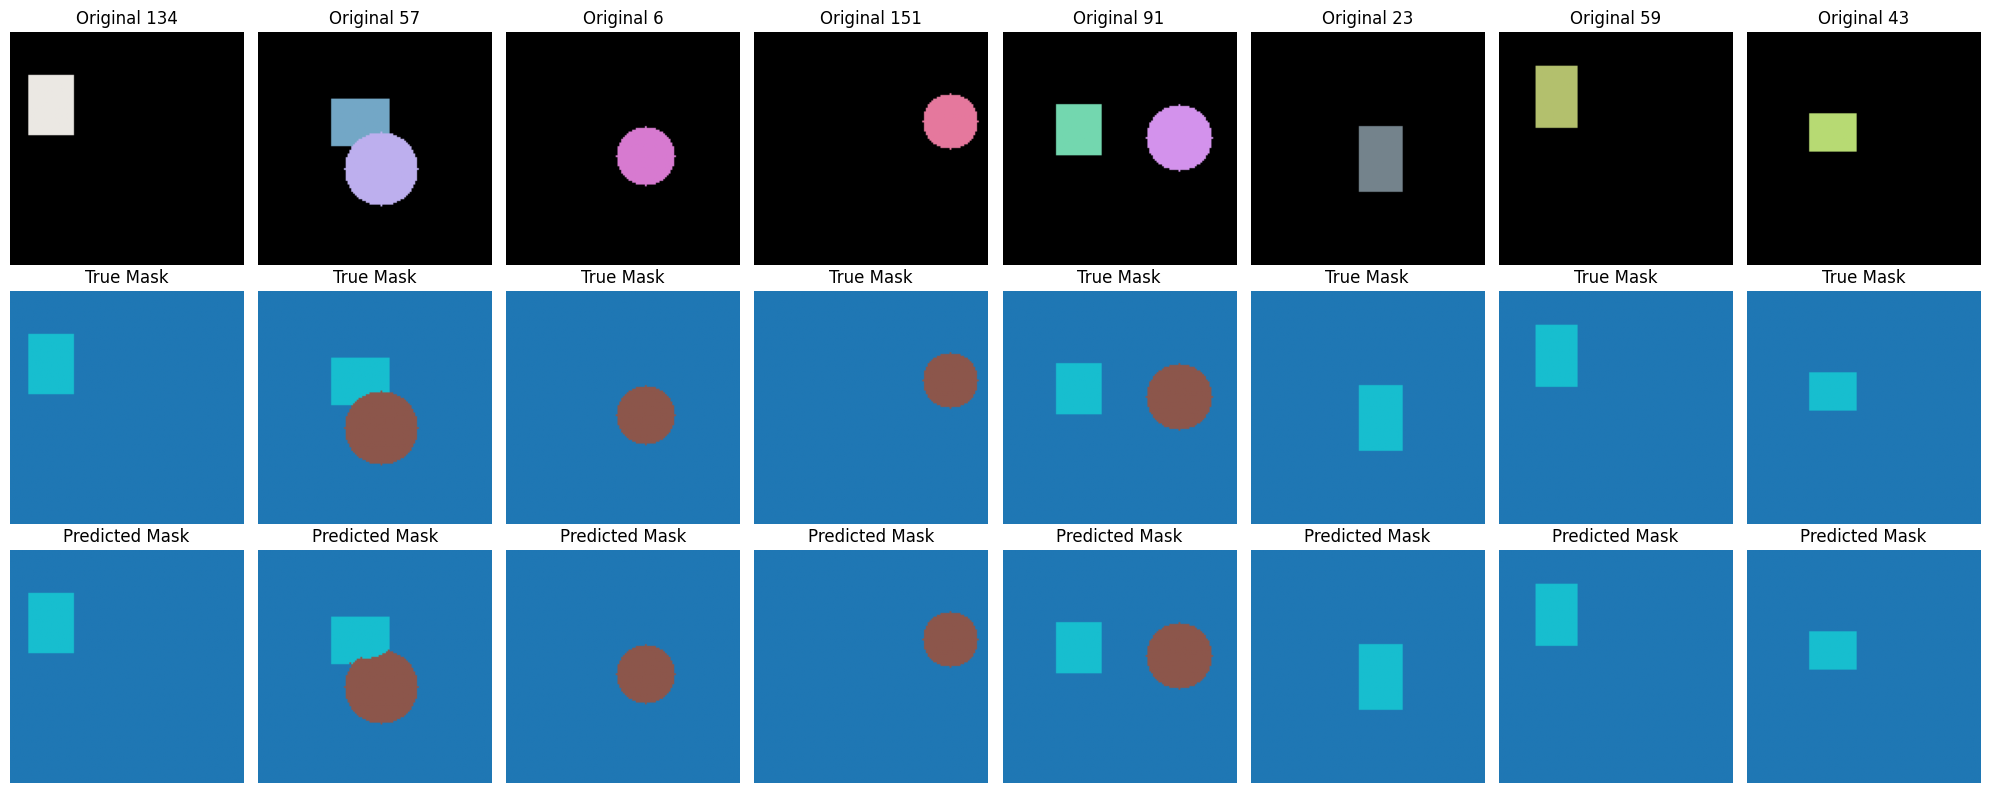

In [ ]:
def predict_and_visualize(model, test_dataset, device, num_samples=8):
    model.eval()

    # Get random samples from test set
    indices = np.random.choice(len(test_dataset), num_samples, replace=False)

    fig, axes = plt.subplots(3, num_samples, figsize=(20, 8))

    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, true_mask = test_dataset[idx]

            # Make prediction
            image_batch = image.unsqueeze(0).to(device)
            output = model(image_batch)
            pred_mask = torch.argmax(output, dim=1).cpu().numpy()[0]

            # Convert image for display
            display_image = image.permute(1, 2, 0).numpy()

            # Plot original image
            axes[0, i].imshow(display_image)
            axes[0, i].set_title(f'Original {idx}')
            axes[0, i].axis('off')

            # Plot true mask
            axes[1, i].imshow(true_mask.numpy(), cmap='tab10', vmax=2)
            axes[1, i].set_title('True Mask')
            axes[1, i].axis('off')

            # Plot predicted mask
            axes[2, i].imshow(pred_mask, cmap='tab10', vmax=2)
            axes[2, i].set_title('Predicted Mask')
            axes[2, i].axis('off')

            # # Calculate IoU for this sample
            # sample_ious = calculate_iou(torch.tensor(pred_mask), true_mask)
            # mean_iou = np.nanmean(sample_ious)
            # axes[2, i].text(0.5, -0.1, f'IoU: {mean_iou:.3f}',
            #               ha='center', va='top', transform=axes[2, i].transAxes)

    plt.tight_layout()
    plt.show()

# Visualize predictions
predict_and_visualize(model, test_dataset, device, num_samples=8)